In [1]:
!pip -q install kagglehub tensorflow opencv-python matplotlib pillow

In [2]:
import tensorflow as tf

print('TensorFlow version:', tf.__version__)
print('Available GPU devices:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
Available GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
import kagglehub

MODEL_HANDLE = 'tensorflow/mask-rcnn-inception-resnet-v2/TensorFlow2/1024x1024/1'
model_dir = kagglehub.model_download(MODEL_HANDLE)

print('Model downloaded to:', model_dir)

Model downloaded to: /kaggle/input/mask-rcnn-inception-resnet-v2/tensorflow2/1024x1024/1


In [5]:
import tensorflow as tf

model = tf.saved_model.load(model_dir)
print('Model loaded successfully.')
print('Available signatures:', list(model.signatures.keys()))

infer = model.signatures['serving_default']
print('Inference function is ready.')

Model loaded successfully.
Available signatures: ['serving_default']
Inference function is ready.


In [15]:
from google.colab import files

uploaded = files.upload()
image_paths = list(uploaded.keys())

print('Uploaded images:')
for path in image_paths:
    print('-', path)

print('\nNumber of uploaded images:', len(image_paths))

Saving image 1-.jpg to image 1-.jpg
Saving image 5.jpg to image 5 (1).jpg
Saving image 4.jpg to image 4 (1).jpg
Saving image 3.jpg to image 3 (1).jpg
Saving image 2.jpg to image 2 (1).jpg
Uploaded images:
- image 1-.jpg
- image 5 (1).jpg
- image 4 (1).jpg
- image 3 (1).jpg
- image 2 (1).jpg

Number of uploaded images: 5


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import os

In [17]:
COCO_LABELS = {
    1: 'person', 2: 'bicycle', 3: 'car', 4: 'motorcycle', 5: 'airplane',
    6: 'bus', 7: 'train', 8: 'truck', 9: 'boat', 10: 'traffic light',
    11: 'fire hydrant', 13: 'stop sign', 14: 'parking meter', 15: 'bench',
    16: 'bird', 17: 'cat', 18: 'dog', 19: 'horse', 20: 'sheep', 21: 'cow',
    22: 'elephant', 23: 'bear', 24: 'zebra', 25: 'giraffe', 27: 'backpack',
    28: 'umbrella', 31: 'handbag', 32: 'tie', 33: 'suitcase', 34: 'frisbee',
    35: 'skis', 36: 'snowboard', 37: 'sports ball', 38: 'kite', 39: 'baseball bat',
    40: 'baseball glove', 41: 'skateboard', 42: 'surfboard', 43: 'tennis racket',
    44: 'bottle', 46: 'wine glass', 47: 'cup', 48: 'fork', 49: 'knife',
    50: 'spoon', 51: 'bowl', 52: 'banana', 53: 'apple', 54: 'sandwich',
    55: 'orange', 56: 'broccoli', 57: 'carrot', 58: 'hot dog', 59: 'pizza',
    60: 'donut', 61: 'cake', 62: 'chair', 63: 'couch', 64: 'potted plant',
    65: 'bed', 67: 'dining table', 70: 'toilet', 72: 'tv', 73: 'laptop',
    74: 'mouse', 75: 'remote', 76: 'keyboard', 77: 'cell phone', 78: 'microwave',
    79: 'oven', 80: 'toaster', 81: 'sink', 82: 'refrigerator', 84: 'book',
    85: 'clock', 86: 'vase', 87: 'scissors', 88: 'teddy bear', 89: 'hair drier',
    90: 'toothbrush'
}

In [18]:
def load_image(path):
    img = Image.open(path).convert('RGB')
    img_np = np.array(img)
    return img_np


def run_inference(image_np):
    input_tensor = tf.convert_to_tensor(image_np, dtype=tf.uint8)
    input_tensor = tf.expand_dims(input_tensor, axis=0)
    outputs = infer(input_tensor)
    return {k: v.numpy() for k, v in outputs.items()}


def get_output_key(outputs, possible_keys):
    for key in possible_keys:
        if key in outputs:
            return key
    return None


def extract_outputs(outputs, score_threshold=0.5):
    score_key = get_output_key(outputs, ['detection_scores', 'detection_score'])
    class_key = get_output_key(outputs, ['detection_classes', 'detection_class_entities', 'detection_class_labels'])
    box_key = get_output_key(outputs, ['detection_boxes', 'detection_box'])
    mask_key = get_output_key(outputs, ['detection_masks', 'detection_mask'])

    if score_key is None or class_key is None or box_key is None:
        raise ValueError(f'Expected detection keys not found. Available keys: {list(outputs.keys())}')

    if 'num_detections' in outputs:
        num = int(outputs['num_detections'][0])
    else:
        num = outputs[score_key].shape[1]

    boxes = outputs[box_key][0][:num]
    scores = outputs[score_key][0][:num]
    classes_raw = outputs[class_key][0][:num]

    if classes_raw.dtype.kind in ['U', 'S', 'O']:
        classes = classes_raw
    else:
        classes = classes_raw.astype(np.int32)

    masks = None
    if mask_key is not None:
        masks = outputs[mask_key][0][:num]

    keep = scores >= score_threshold
    boxes = boxes[keep]
    scores = scores[keep]
    classes = classes[keep]
    if masks is not None:
        masks = masks[keep]

    return boxes, classes, scores, masks


def get_class_name(class_id):
    if isinstance(class_id, (bytes, np.bytes_)):
        return class_id.decode('utf-8')
    if isinstance(class_id, str):
        return class_id
    return COCO_LABELS.get(int(class_id), f'class_{int(class_id)}')


def denormalize_box(box, h, w):
    y1, x1, y2, x2 = box
    return int(y1 * h), int(x1 * w), int(y2 * h), int(x2 * w)


def overlay_mask_on_image(image, mask, box, color=(0, 255, 0), alpha=0.4):
    h, w, _ = image.shape
    y1, x1, y2, x2 = denormalize_box(box, h, w)

    y1 = max(0, y1)
    x1 = max(0, x1)
    y2 = min(h, y2)
    x2 = min(w, x2)

    if y2 <= y1 or x2 <= x1:
        return image

    mask_resized = cv2.resize(mask, (x2 - x1, y2 - y1))
    mask_bin = (mask_resized > 0.5).astype(np.uint8)

    overlay = image.copy()
    region = overlay[y1:y2, x1:x2]
    color_arr = np.array(color, dtype=np.uint8)

    region[mask_bin == 1] = ((1 - alpha) * region[mask_bin == 1] + alpha * color_arr).astype(np.uint8)
    overlay[y1:y2, x1:x2] = region
    return overlay


def draw_predictions(image_np, boxes, classes, scores, masks=None):
    img = image_np.copy()
    h, w, _ = img.shape

    for i in range(len(boxes)):
        y1, x1, y2, x2 = denormalize_box(boxes[i], h, w)
        y1 = max(0, y1)
        x1 = max(0, x1)
        y2 = min(h, y2)
        x2 = min(w, x2)

        if masks is not None:
            img = overlay_mask_on_image(img, masks[i], boxes[i])

        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

        label = get_class_name(classes[i])
        text = f'{label}: {scores[i]:.2f}'
        cv2.putText(img, text, (x1, max(y1 - 10, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    return img

In [19]:
test_img = load_image(image_paths[0])
test_outputs = run_inference(test_img)

print('Output keys:')
for k in test_outputs.keys():
    print(k, test_outputs[k].shape)

Output keys:
box_classifier_features (300, 9, 9, 1536)
proposal_boxes (1, 300, 4)
proposal_boxes_normalized (1, 300, 4)
detection_classes (1, 100)
rpn_box_predictor_features (1, 64, 64, 512)
rpn_objectness_predictions_with_background (1, 49152, 2)
rpn_features_to_crop (1, 64, 64, 1088)
class_predictions_with_background (300, 91)
anchors (49152, 4)
image_shape (4,)
num_proposals (1,)
mask_predictions (100, 90, 33, 33)
raw_detection_boxes (1, 300, 4)
detection_masks (1, 100, 33, 33)
detection_boxes (1, 100, 4)
rpn_box_encodings (1, 49152, 4)
final_anchors (1, 300, 4)
detection_multiclass_scores (1, 100, 91)
refined_box_encodings (300, 90, 4)
raw_detection_scores (1, 300, 91)
num_detections (1,)
detection_anchor_indices (1, 100)
detection_scores (1, 100)


In [20]:
results_05 = []

for path in image_paths:
    image_np = load_image(path)
    outputs = run_inference(image_np)
    boxes, classes, scores, masks = extract_outputs(outputs, score_threshold=0.5)
    vis_img = draw_predictions(image_np, boxes, classes, scores, masks)
    results_05.append((path, image_np, vis_img, boxes, classes, scores, masks))

print('Inference completed with threshold = 0.5')

Inference completed with threshold = 0.5


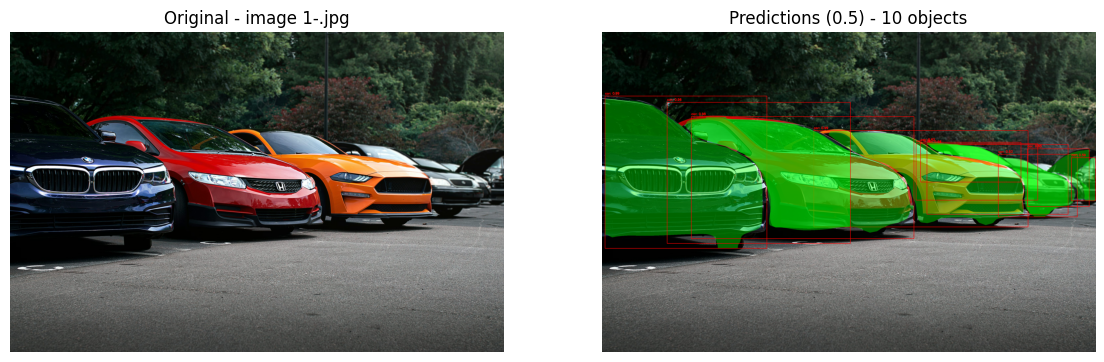

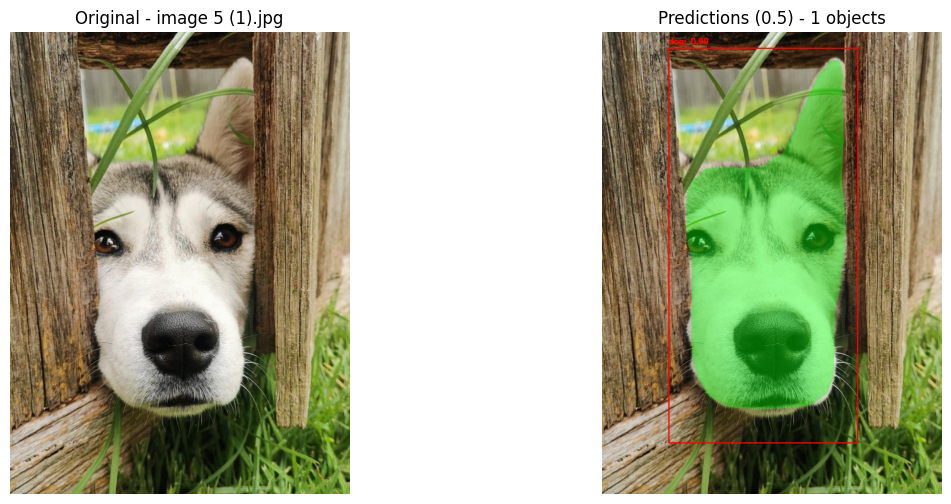

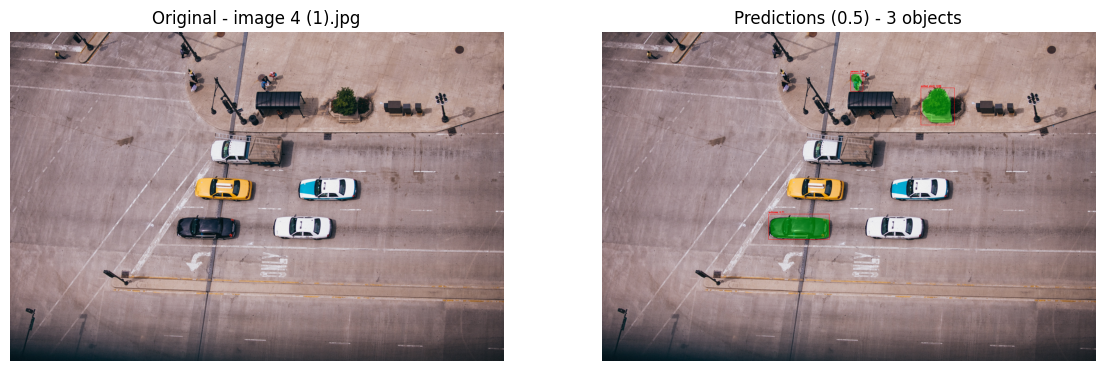

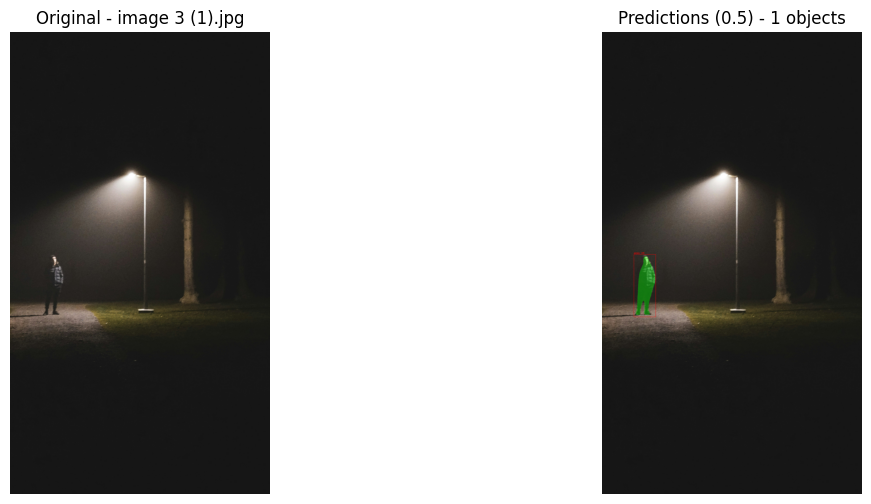

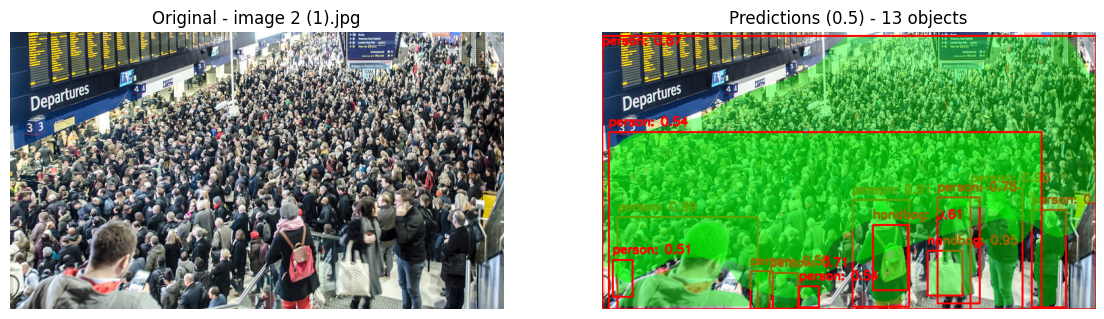

In [21]:
for path, original, vis_img, boxes, classes, scores, masks in results_05:
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title(f'Original - {path}')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(vis_img)
    plt.title(f'Predictions (0.5) - {len(scores)} objects')
    plt.axis('off')

    plt.show()

In [22]:
for path, original, vis_img, boxes, classes, scores, masks in results_05:
    print('=' * 80)
    print('Image:', path)
    print('Detected objects:', len(scores))

    for i in range(len(scores)):
        label = get_class_name(classes[i])
        print(f'Object {i+1}')
        print('  Class:', label)
        print('  Score:', float(scores[i]))
        print('  Bounding Box:', boxes[i].tolist())
        if masks is not None:
            print('  Mask shape:', masks[i].shape)

Image: image 1-.jpg
Detected objects: 10
Object 1
  Class: car
  Score: 0.9928432703018188
  Bounding Box: [0.20009727776050568, 0.006248295307159424, 0.6757853627204895, 0.3339819610118866]
  Mask shape: (33, 33)
Object 2
  Class: car
  Score: 0.9881624579429626
  Bounding Box: [0.308023065328598, 0.4286874532699585, 0.6092488765716553, 0.8624677658081055]
  Mask shape: (33, 33)
Object 3
  Class: car
  Score: 0.9824731349945068
  Bounding Box: [0.2646251320838928, 0.18090268969535828, 0.645456075668335, 0.6314057111740112]
  Mask shape: (33, 33)
Object 4
  Class: car
  Score: 0.9756022691726685
  Bounding Box: [0.351032018661499, 0.6577872633934021, 0.5697474479675293, 0.9435005784034729]
  Mask shape: (33, 33)
Object 5
  Class: car
  Score: 0.958554208278656
  Bounding Box: [0.2194623351097107, 0.13182185590267181, 0.6606488823890686, 0.5027185082435608]
  Mask shape: (33, 33)
Object 6
  Class: car
  Score: 0.9326741099357605
  Bounding Box: [0.38219109177589417, 0.80218505859375, 0.

In [23]:
results_03 = []

for path in image_paths:
    image_np = load_image(path)
    outputs = run_inference(image_np)
    boxes, classes, scores, masks = extract_outputs(outputs, score_threshold=0.3)
    vis_img = draw_predictions(image_np, boxes, classes, scores, masks)
    results_03.append((path, image_np, vis_img, boxes, classes, scores, masks))

print('Inference completed with threshold = 0.3')

Inference completed with threshold = 0.3


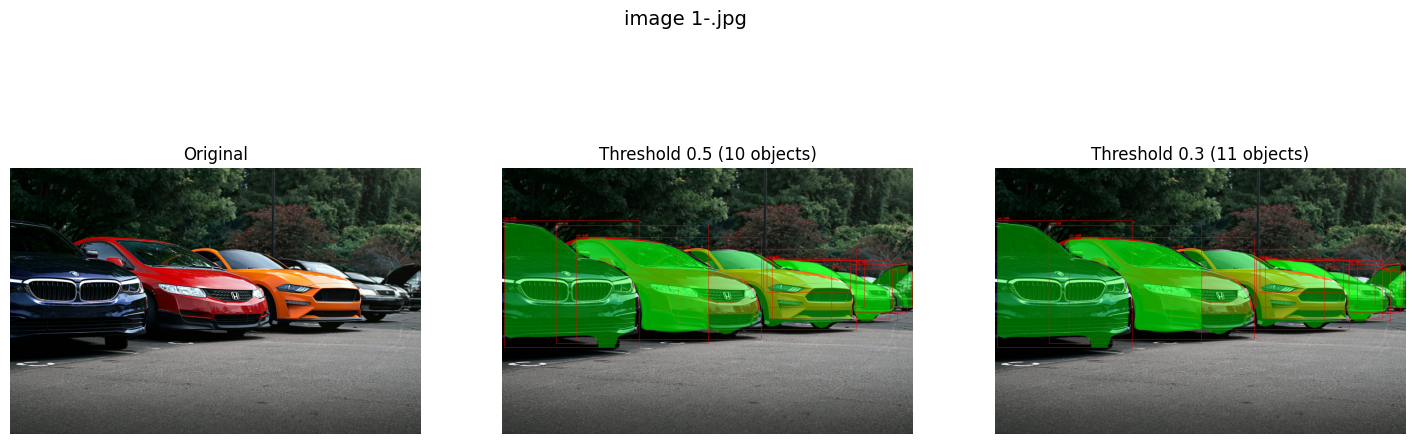

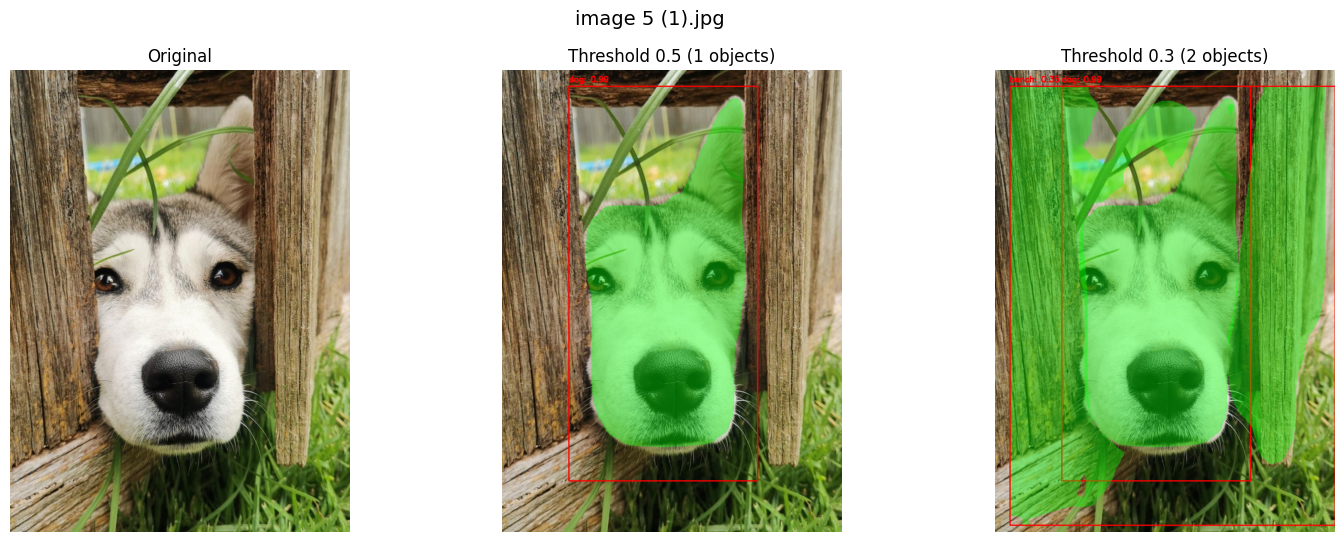

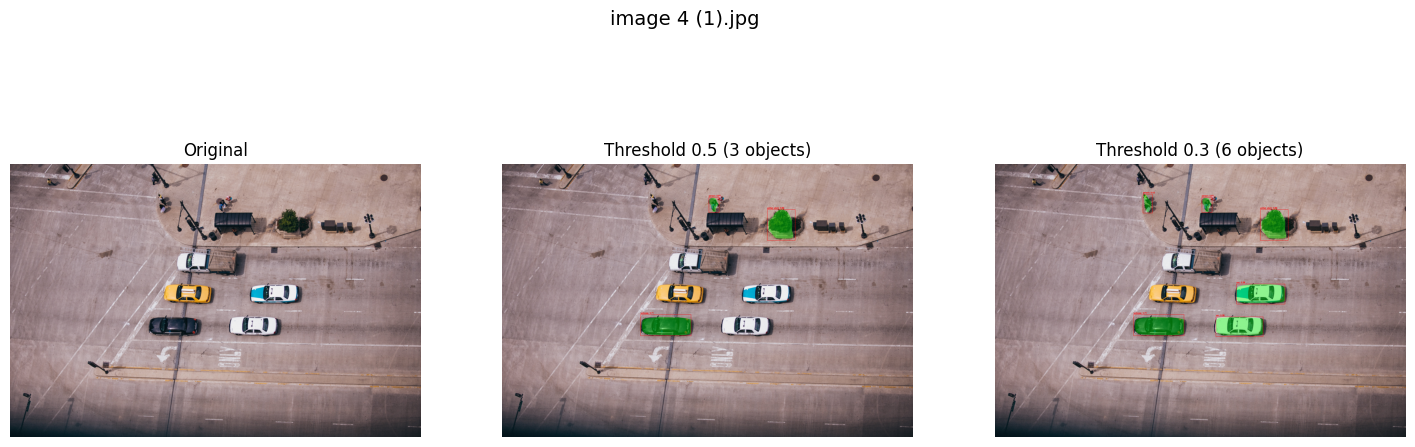

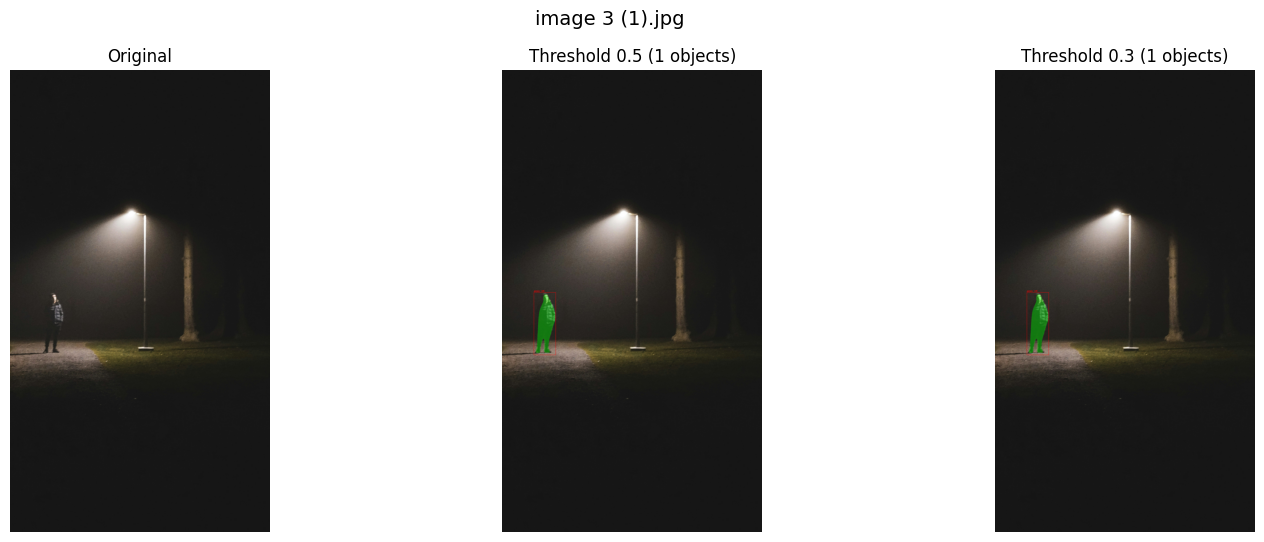

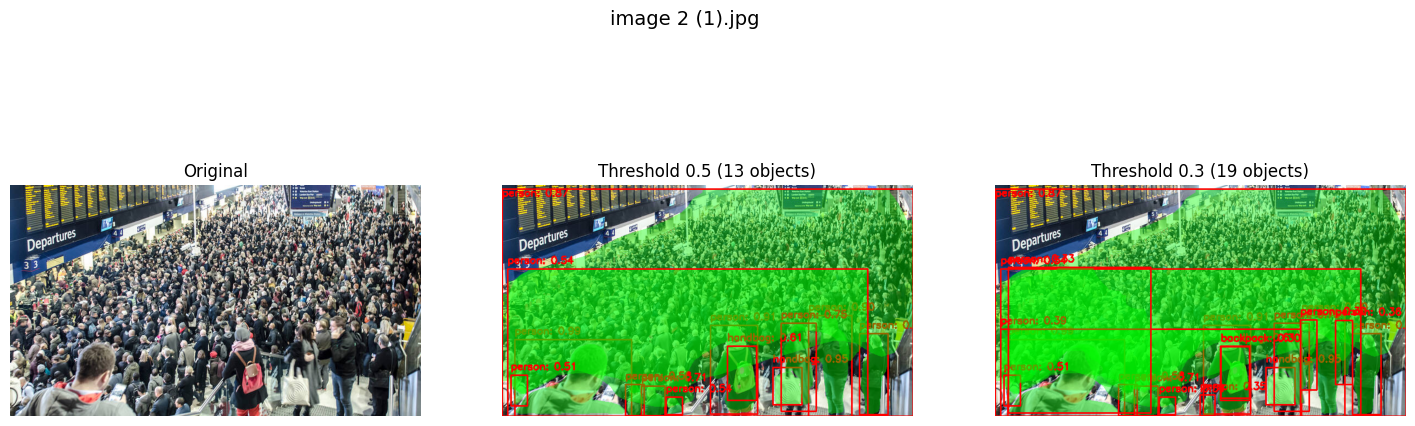

In [24]:
for idx in range(len(image_paths)):
    path_05, original, vis_05, boxes_05, classes_05, scores_05, masks_05 = results_05[idx]
    path_03, original, vis_03, boxes_03, classes_03, scores_03, masks_03 = results_03[idx]

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(original)
    plt.title('Original')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(vis_05)
    plt.title(f'Threshold 0.5 ({len(scores_05)} objects)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(vis_03)
    plt.title(f'Threshold 0.3 ({len(scores_03)} objects)')
    plt.axis('off')

    plt.suptitle(path_05, fontsize=14)
    plt.show()

In [25]:
os.makedirs('results_05', exist_ok=True)
os.makedirs('results_03', exist_ok=True)

for path, original, vis_img, boxes, classes, scores, masks in results_05:
    save_path = os.path.join('results_05', f'pred_05_{os.path.basename(path)}')
    Image.fromarray(vis_img).save(save_path)

for path, original, vis_img, boxes, classes, scores, masks in results_03:
    save_path = os.path.join('results_03', f'pred_03_{os.path.basename(path)}')
    Image.fromarray(vis_img).save(save_path)

print('Saved all result images.')

Saved all result images.
